QK is about using quantum computer to estimate kernel.
Since from classical feature space, you don't want to work explicitly with feature vectors, you want to work with kernel function. You need a way to compute the kernel function from QC and use that in many classical algorithm.

Classically, we are interested in feature maps for which the kernel function is easy to evaluate. This often means finding a kernel function for which the inner product in the feature-mapped space can be written in terms of the original data vectors, without having to ever construct the new vector on the new feature space.
In the method of quantum kernels, the feature mapping is done by a quantum circuit, and the kernel is estimated using measurements on that circuit and the relative measurement probabilities

QK advantage is not so much the fact that we can represent data in high dimensionality feature Hilbert space but above all the fact that if the classical method kernels are hard to classically estimate, then we can expect to do better with QK.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Two mock data points, including category labels, as in training
small_data = [
    [-0.194, 0.114, -0.006, 0.301, -0.359, -0.088, -0.156, 0.342, -0.016, 0.143, 1],
    [-0.1, 0.002, 0.244, 0.127, -0.064, -0.086, 0.072, 0.043, -0.053, 0.02, -1],
]

# Data points with labels removed, for inner product
train_data = [small_data[0][:-1], small_data[1][:-1]]

In [6]:
# from qiskit.circuit.library import zz_feature_map
# fm = zz_feature_map(feature_dimension=np.shape(train_data)[1], entanglement='linear', reps=1)

from qiskit.circuit.library import z_feature_map

fm = z_feature_map(feature_dimension=np.shape(train_data)[1])


unitary1 = fm.assign_parameters(train_data[0])
unitary2 = fm.assign_parameters(train_data[1])

circuit depth =  9


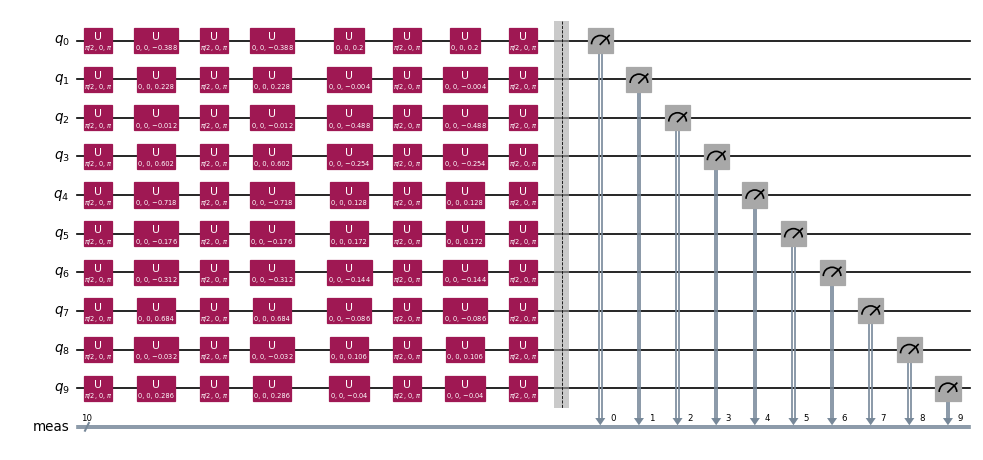

In [7]:
from qiskit.circuit.library import unitary_overlap


overlap_circ = unitary_overlap(unitary1, unitary2)  # to combine them
overlap_circ.measure_all()

print("circuit depth = ", overlap_circ.decompose().depth())
overlap_circ.decompose().draw("mpl", scale=0.6, style="iqp")

In [8]:
# Import needed packages
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService

# Get the least busy backend
service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=fm.num_qubits
)
print(backend)

qiskit_runtime_service.__init__:WARNING:2026-06-26 15:45:37,619: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: qgss2025-00. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-26 15:45:37,934: Loading instance: qgss2025-00, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-26 15:45:41,069: Using instance: qgss2025-00, plan: open


<IBMBackend('ibm_kingston')>


In [9]:
# Apply level 2/3 optimization to our overlap circuit
pm = generate_preset_pass_manager(optimization_level=1, backend=backend, translation_method="translator")
overlap_ibm = pm.run(overlap_circ)

In [10]:
print("circuit depth = ", overlap_ibm.decompose().depth())
overlap_ibm.decompose().depth(lambda instr: len(instr.qubits) > 1)

circuit depth =  10


1

In [14]:
# Import our runtime primitive
from qiskit_ibm_runtime import Session, SamplerV2 as Sampler
from qiskit.primitives import StatevectorSampler

from qiskit_ibm_runtime import Options, Session, Sampler

REAL_HW = False


num_shots = 10000

# Use sampler and get the counts
sampler = Sampler(mode=backend) if REAL_HW else StatevectorSampler()
circ = overlap_ibm if REAL_HW else overlap_circ 
results = sampler.run([circ], shots=num_shots).result()
# .get_counts() returns counts associated with a state abeled by bit results such as |001101...01>.
counts_bit = results[0].data.meas.get_counts()
# .get_int_counts returns the same counts, but labeled by integer equivalent of the above bit string.
counts = results[0].data.meas.get_int_counts()

In [15]:
counts.get(0, 0.0) / num_shots

0.6882

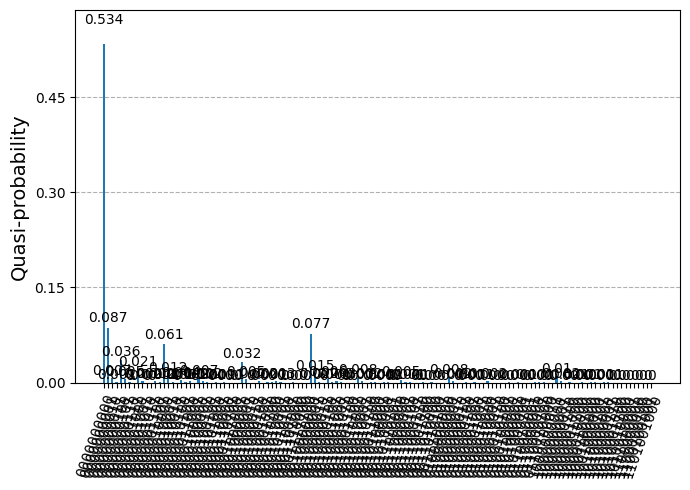

In [13]:
from qiskit.visualization import plot_distribution

plot_distribution(counts_bit)

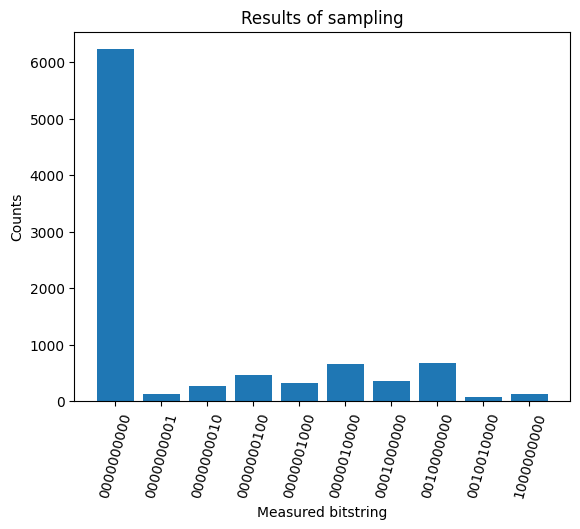

In [14]:
def visualize_counts(probs, num_qubits):
    """Visualize the outputs from the Qiskit Sampler primitive."""
    zero_prob = probs.get(0, 0.0)
    top_10 = dict(sorted(probs.items(), key=lambda item: item[1], reverse=True)[:10])
    top_10.update({0: zero_prob})
    by_key = dict(sorted(top_10.items(), key=lambda item: item[0]))
    xvals, yvals = list(zip(*by_key.items()))
    xvals = [bin(xval)[2:].zfill(num_qubits) for xval in xvals]
    plt.bar(xvals, yvals)
    plt.xticks(rotation=75)
    plt.title("Results of sampling")
    plt.xlabel("Measured bitstring")
    plt.ylabel("Counts")
    plt.show()


visualize_counts(counts, overlap_circ.num_qubits)

# Full matrix computation

In [24]:
!wget https://raw.githubusercontent.com/qiskit-community/prototype-quantum-kernel-training/main/data/dataset_graph7.csv

--2026-06-05 15:02:38--  https://raw.githubusercontent.com/qiskit-community/prototype-quantum-kernel-training/main/data/dataset_graph7.csv
Risoluzione di raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connessione a raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connesso.
Richiesta HTTP inviata, in attesa di risposta... 200 OK
Lunghezza: 49405 (48K) [text/plain]
Salvataggio in: «dataset_graph7.csv»

dataset_graph7.csv  100%[===================>]  48,25K  --.-KB/s    in 0,01s   

2026-06-05 15:02:38 (3,82 MB/s) - «dataset_graph7.csv» salvato [49405/49405]



In [25]:
df = pd.read_csv("dataset_graph7.csv", sep=",", header=None)

# Prepare training data

train_size = 90
X_train = df.values[0:train_size, :-1]
train_labels = df.values[0:train_size, -1]

# Prepare testing data
test_size = 30
X_test = df.values[train_size : train_size + test_size, :-1]
test_labels = df.values[train_size : train_size + test_size, -1]

In [31]:
# Empty kernel matrix
num_samples = np.shape(X_train)[0]
kernel_matrix = np.full((num_samples, num_samples), np.nan)
test_matrix = np.full((test_size, num_samples), np.nan)

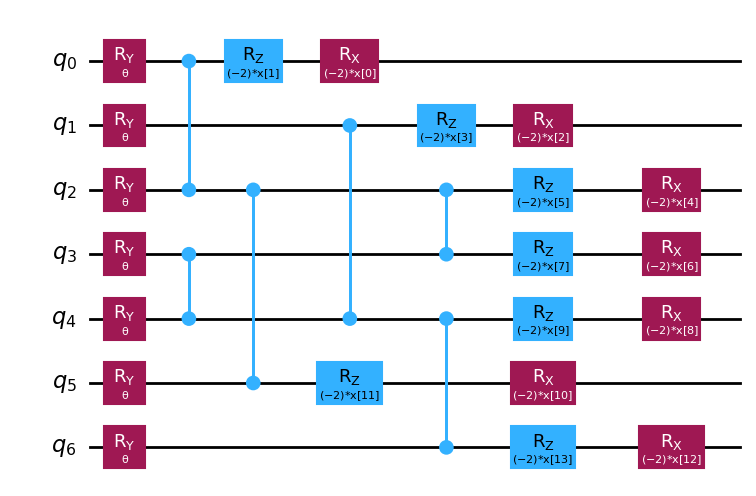

In [32]:
from qiskit.circuit import Parameter, ParameterVector, QuantumCircuit

# Prepare feature map for computing overlap. Always pay attention to circuit depth.
num_features = np.shape(X_train)[1]
num_qubits = int(num_features / 2)

# To use a custom feature map use the lines below.
entangler_map = [[0, 2], [3, 4], [2, 5], [1, 4], [2, 3], [4, 6]]

fm = QuantumCircuit(num_qubits)
training_param = Parameter("θ")
feature_params = ParameterVector("x", num_qubits * 2)
fm.ry(training_param, fm.qubits)
for cz in entangler_map:
    fm.cz(cz[0], cz[1])
for i in range(num_qubits):
    fm.rz(-2 * feature_params[2 * i + 1], i)
    fm.rx(-2 * feature_params[2 * i], i)

display(fm.draw(output='mpl'))

In [35]:
# To use a simulator
from qiskit.primitives import StatevectorSampler

# Remember to insert your token in the QiskitRuntimeService constructor to use real quantum computers
# service = QiskitRuntimeService()
# backend = service.least_busy(
#    operational=True, simulator=False, min_num_qubits=fm.num_qubits
# )

num_shots = 10000

# Evaluate the problem using state vector-based primitives from Qiskit.
sampler = StatevectorSampler()

for x1 in range(0, train_size):
    for x2 in range(x1 + 1, train_size):
        unitary1 = fm.assign_parameters(list(X_train[x1]) + [np.pi / 2])
        unitary2 = fm.assign_parameters(list(X_train[x2]) + [np.pi / 2])

        # Create the overlap circuit
        overlap_circ = unitary_overlap(unitary1, unitary2)
        overlap_circ.measure_all()

        # These lines run the qiskit sampler primitive.
        counts = (
            sampler.run([overlap_circ], shots=num_shots)
            .result()[0]
            .data.meas.get_int_counts()
        )

        # Assign the probability of the 0 state to the kernel matrix, and the transposed element (since this is an inner product)
        kernel_matrix[x1, x2] = counts.get(0, 0.0) / num_shots
        kernel_matrix[x2, x1] = counts.get(0, 0.0) / num_shots
    # Fill in on-diagonal elements with 1, again, since this is an inner-product corresponding to probability (or alter the code to check these entries and verify they yield 1)
    kernel_matrix[x1, x1] = 1

print("training done")

# Similar process to above, but for testing data.
# The SVM needs to know how similar each test point is to the support vectors
for x1 in range(0, test_size):
    for x2 in range(0, train_size):
        unitary1 = fm.assign_parameters(list(X_test[x1]) + [np.pi / 2])
        unitary2 = fm.assign_parameters(list(X_train[x2]) + [np.pi / 2])

        # Create the overlap circuit
        overlap_circ = unitary_overlap(unitary1, unitary2)
        overlap_circ.measure_all()

        counts = (
            sampler.run([overlap_circ], shots=num_shots)
            .result()[0]
            .data.meas.get_int_counts()
        )

        test_matrix[x1, x2] = counts.get(0, 0.0) / num_shots

print("test matrix done")

training done
test matrix done


# Post process

In [36]:
# import a support vector classifier from a classical ML package.
from sklearn.svm import SVC

# Specify that you want to use a pre-computed kernel matrix
qml_svc = SVC(kernel="precomputed")

# Feed in the pre-computed matrix and the labels of the training data. The classical algorithm gives you a fit.
qml_svc.fit(kernel_matrix, train_labels)

# Now use the .score to test your data, using the matrix of test data, and test labels as your inputs.
qml_score_precomputed_kernel = qml_svc.score(test_matrix, test_labels)
print(f"Precomputed kernel classification test score: {qml_score_precomputed_kernel}")

Precomputed kernel classification test score: 1.0


This is great, and it shows that QKE can work. But that is very different from quantum advantage. Classical kernels would likely have been able to solve this classification problem with 100% accuracy as well